In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *

from pyspark.ml.classification import (
    LogisticRegression,
    RandomForestClassifier,
    GBTClassifier
)

from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator
)


from pyspark.ml.tuning import (
    ParamGridBuilder,
    CrossValidator,
    TrainValidationSplit
)
from pyspark.mllib.evaluation import MulticlassMetrics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("HotelBooking") \
    .getOrCreate()

In [3]:
train_df = spark.read.parquet("data/hotel_train_vectorized.parquet")
test_df = spark.read.parquet("data/hotel_test_vectorized.parquet")

In [4]:
train_df.printSchema()
test_df.printSchema()

root
 |-- features: vector (nullable = true)
 |-- label: integer (nullable = true)

root
 |-- features: vector (nullable = true)
 |-- label: integer (nullable = true)



In [5]:
print("Train:", train_df.count())
print("Test:", test_df.count())

Train: 94868
Test: 23453


In [6]:
#kiểm tra mất cn bằng lớp
train_df.groupBy("label").count().show()

+-----+-----+
|label|count|
+-----+-----+
|    1|35345|
|    0|59523|
+-----+-----+



In [7]:
from pyspark.sql.functions import col

total = train_df.count()

train_df.groupBy("label") \
    .count() \
    .withColumn(
        "percentage",
        col("count") * 100 / total
    ) \
    .show()

+-----+-----+-----------------+
|label|count|       percentage|
+-----+-----+-----------------+
|    1|35345|37.25703082177341|
|    0|59523|62.74296917822659|
+-----+-----+-----------------+



In [8]:
print(train_df.first())


Row(features=SparseVector(534, {0: 1.0, 6: 1.0, 180: 1.0, 186: 1.0, 190: 1.0, 199: 1.0, 202: 1.0, 207: 1.0, 522: 1.0, 523: -0.9121, 524: -1.4962, 525: -0.9632, 526: -0.8541, 527: -0.122, 528: -0.2327, 529: -0.1322, 530: -0.2549, 531: -0.7194}), label=0)


In [9]:
#khởi tạo và huấn luyện
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=100,
    regParam=0.0,
    elasticNetParam=0.0
)

In [10]:
lr_model = lr.fit(train_df)

In [11]:
#dự đoán trên test
pred_lr = lr_model.transform(test_df)

In [12]:
pred_lr.select(
    "label",
    "prediction",
    "probability"
).show(10, truncate=False)

+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|0    |0.0       |[0.7497105289028031,0.2502894710971969] |
|0    |0.0       |[0.9414279561495901,0.05857204385040993]|
|0    |0.0       |[0.7644874888539396,0.23551251114606042]|
|0    |0.0       |[0.7338917825030162,0.26610821749698377]|
|0    |0.0       |[0.9538163386433459,0.04618366135665408]|
|0    |0.0       |[0.760022377591892,0.23997762240810805] |
|1    |0.0       |[0.6752902087869175,0.3247097912130825] |
|1    |0.0       |[0.6815024221227057,0.31849757787729427]|
|0    |1.0       |[0.38126915850458165,0.6187308414954183]|
|0    |0.0       |[0.686003895630309,0.31399610436969105] |
+-----+----------+----------------------------------------+
only showing top 10 rows


In [13]:
#chỉ số đánh giá
from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator,
    BinaryClassificationEvaluator
)

accuracy = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
).evaluate(pred_lr)

precision = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
).evaluate(pred_lr)

recall = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
).evaluate(pred_lr)

f1 = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
).evaluate(pred_lr)

auc = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
).evaluate(pred_lr)

print("=" * 50)
print("LOGISTIC REGRESSION")
print("=" * 50)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

LOGISTIC REGRESSION
Accuracy : 0.8214
Precision: 0.8202
Recall   : 0.8214
F1 Score : 0.8178
ROC-AUC  : 0.9031


In [14]:
#confusion matrix
from pyspark.sql.functions import col
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# lấy prediction về pandas
y_true = (
    pred_lr
    .select("label")
    .toPandas()["label"]
)

y_pred = (
    pred_lr
    .select("prediction")
    .toPandas()["prediction"]
)

# confusion matrix
cm = confusion_matrix(y_true, y_pred)

print(cm)

[[13304  1420]
 [ 2769  5960]]


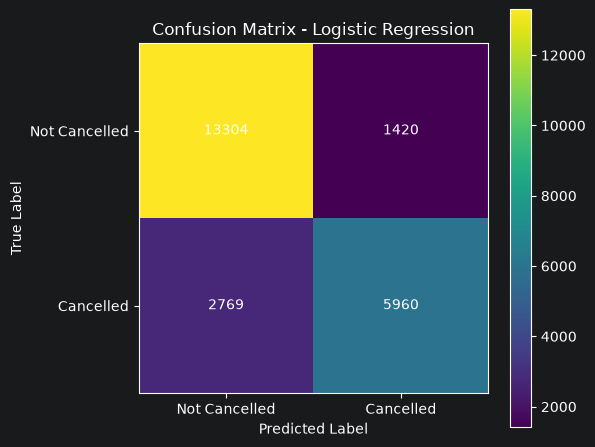

In [15]:
plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.title("Confusion Matrix - Logistic Regression")
plt.colorbar()

classes = ["Not Cancelled", "Cancelled"]

plt.xticks(np.arange(len(classes)), classes)
plt.yticks(np.arange(len(classes)), classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [16]:
#tính ROC

from sklearn.metrics import roc_curve, auc

pdf = pred_lr.select(
    "label",
    "probability"
).toPandas()

y_true = pdf["label"]

y_score = pdf["probability"].apply(
    lambda x: float(x[1])
)
fpr, tpr, thresholds = roc_curve(
    y_true,
    y_score
)

roc_auc = auc(
    fpr,
    tpr
)

print("AUC =", roc_auc)

AUC = 0.903072208943954


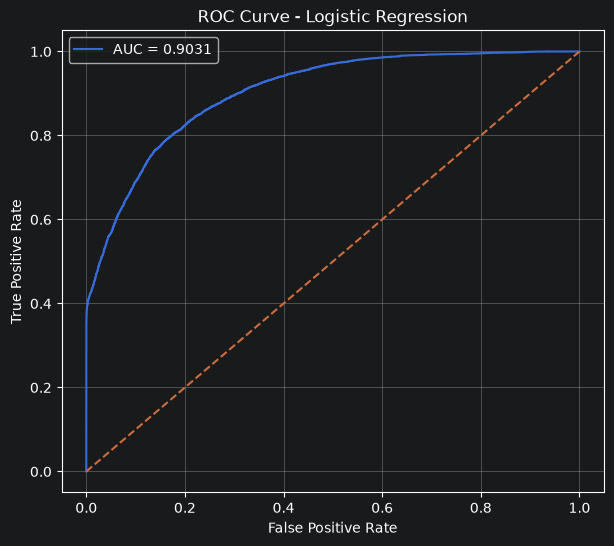

In [17]:
#vẽ ROC curve
plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve - Logistic Regression"
)

plt.legend()

plt.grid(True)

plt.show()

In [18]:
# dùng random forest để train
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=100,
    maxDepth=10,
    seed=42
)

rf_model = rf.fit(train_df)
#dự đoán trên tập test
pred_rf = rf_model.transform(test_df)


In [19]:
#kiểm tra
pred_rf.select(
    "label",
    "prediction",
    "probability"
).show(10, truncate=False)

+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|0    |0.0       |[0.7819867197159561,0.21801328028404388]|
|0    |0.0       |[0.6816857187902223,0.3183142812097777] |
|0    |0.0       |[0.6322722665833409,0.36772773341665904]|
|0    |0.0       |[0.734193450813611,0.26580654918638913] |
|0    |0.0       |[0.8240173669874004,0.17598263301259967]|
|0    |0.0       |[0.7577145745248661,0.24228542547513385]|
|1    |0.0       |[0.616545232566555,0.3834547674334449]  |
|1    |0.0       |[0.616545232566555,0.3834547674334449]  |
|0    |0.0       |[0.5932855121538076,0.4067144878461923] |
|0    |0.0       |[0.7672764590173832,0.2327235409826168] |
+-----+----------+----------------------------------------+
only showing top 10 rows


In [20]:
# dùng GBT để train
gbt = GBTClassifier(
    featuresCol="features",
    labelCol="label",
    maxIter=100,
    maxDepth=5,
    seed=42
)

gbt_model = gbt.fit(train_df)
#dự đoán trên tập test
pred_gbt = gbt_model.transform(test_df)

In [21]:
#kiểm tra dự đoán
pred_gbt.select(
    "label",
    "prediction",
    "probability"
).show(10, truncate=False)

+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|0    |0.0       |[0.8176240061935297,0.1823759938064703] |
|0    |0.0       |[0.7691868144420116,0.23081318555798835]|
|0    |1.0       |[0.33209345512524907,0.667906544874751] |
|0    |1.0       |[0.48624832000325785,0.5137516799967421]|
|0    |0.0       |[0.9235396088133148,0.07646039118668524]|
|0    |0.0       |[0.9677335157427805,0.03226648425721945]|
|1    |0.0       |[0.5455565504629577,0.4544434495370423] |
|1    |0.0       |[0.5455565504629577,0.4544434495370423] |
|0    |1.0       |[0.28614862744189096,0.713851372558109] |
|0    |0.0       |[0.967781572437058,0.03221842756294202] |
+-----+----------+----------------------------------------+
only showing top 10 rows


In [22]:
#các chỉ số đánh giá
import builtins
from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator,
    BinaryClassificationEvaluator
)

models = {
    "Logistic Regression": pred_lr,
    "Random Forest": pred_rf,
    "GBTClassifier": pred_gbt
}

results = []

for model_name, pred in models.items():

    accuracy = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="accuracy"
    ).evaluate(pred)

    precision = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="weightedPrecision"
    ).evaluate(pred)

    recall = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="weightedRecall"
    ).evaluate(pred)

    f1 = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="f1"
    ).evaluate(pred)

    auc = BinaryClassificationEvaluator(
        labelCol="label",
        rawPredictionCol="rawPrediction",
        metricName="areaUnderROC"
    ).evaluate(pred)

    results.append([
    model_name,
    builtins.round(accuracy, 4),
    builtins.round(precision, 4),
    builtins.round(recall, 4),
    builtins.round(f1, 4),
    builtins.round(auc, 4)
])

import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8214,0.8202,0.8214,0.8178,0.9031
1,Random Forest,0.7700,0.8309,0.7700,0.7365,0.9019
2,GBTClassifier,0.8546,0.8538,0.8546,0.8527,0.9316


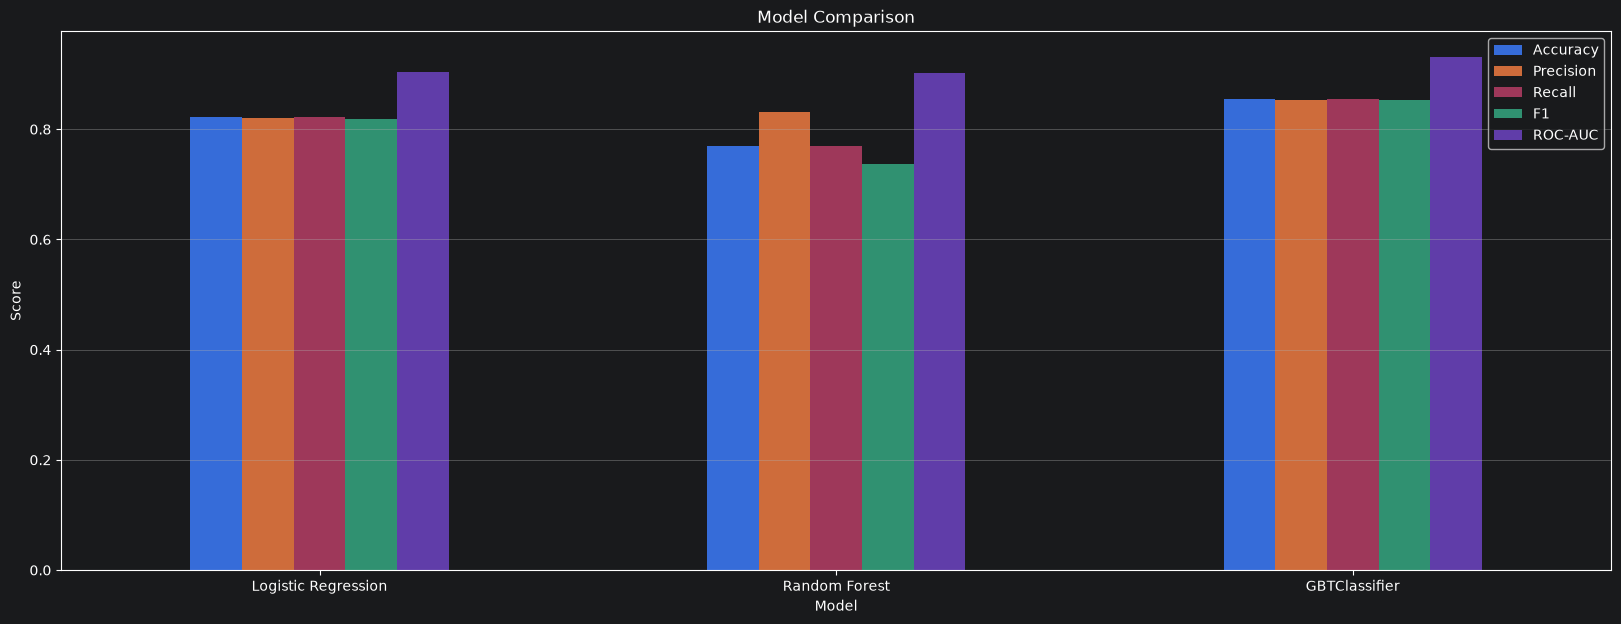

In [23]:
#biểu đồ so sánh
import matplotlib.pyplot as plt

results_df.set_index("Model").plot(
    kind="bar",
    figsize=(20,7)
)

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

In [24]:
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit
from pyspark.ml.evaluation import BinaryClassificationEvaluator

In [25]:
#tạo lại model để tuning
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=100,
    regParam=0.0,
    elasticNetParam=0.0
)

In [26]:
#tạo tham số cần thử
paramGrid_lr = (
    ParamGridBuilder()
    .addGrid(lr.regParam, [0.0, 0.01, 0.1])
    .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0])
    .build()
)

In [27]:
#dùng ROC-AUC để đánh giá
evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

In [28]:
#khởi tạo TrainValidationSplit để chọn bộ tham số tốt nhất
tvs_lr = TrainValidationSplit(
    estimator=lr,
    estimatorParamMaps=paramGrid_lr,
    evaluator=evaluator,
    trainRatio=0.8
)

In [29]:
#chạy tuning
tvs_lr_model = tvs_lr.fit(train_df)

In [30]:
# lấy model tốt nhất
best_lr = tvs_lr_model.bestModel

In [31]:
#xem tham số tốt nhất
print("Best regParam:", best_lr.getRegParam())
print("Best elasticNetParam:", best_lr.getElasticNetParam())
print("Best maxIter:", best_lr.getMaxIter())

Best regParam: 0.0
Best elasticNetParam: 0.0
Best maxIter: 100


In [32]:
# tạo param grid
from pyspark.ml.tuning import ParamGridBuilder

paramGrid_rf = (
    ParamGridBuilder()
    .addGrid(rf.numTrees, [50, 100])
    .addGrid(rf.maxDepth, [5, 10])
    .addGrid(rf.maxBins, [32, 64])
    .build()
)

In [33]:
# dùng ROC-AUC để đánh giá
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

In [34]:
from pyspark.ml.tuning import TrainValidationSplit

tvs_rf = TrainValidationSplit(
    estimator=rf,
    estimatorParamMaps=paramGrid_rf,
    evaluator=evaluator,
    trainRatio=0.8
)

In [35]:
#chạy tuning
tvs_rf_model = tvs_rf.fit(train_df)

In [36]:
#lấy model tốt nhất và xem bộ tham số tối ưu
best_rf = tvs_rf_model.bestModel

print("Best numTrees:", best_rf.getNumTrees)
print("Best maxDepth:", best_rf.getOrDefault("maxDepth"))
print("Best maxBins :", best_rf.getOrDefault("maxBins"))

Best numTrees: 100
Best maxDepth: 10
Best maxBins : 32


In [37]:
#khởi tạo GBT
from pyspark.ml.classification import GBTClassifier

gbt = GBTClassifier(
    featuresCol="features",
    labelCol="label",
    seed=42
)

In [38]:
#tạo param grid
from pyspark.ml.tuning import ParamGridBuilder

paramGrid_gbt = (
    ParamGridBuilder()
    .addGrid(gbt.maxDepth, [5, 10])
    .addGrid(gbt.maxIter, [20, 50])
    .build()
)

In [39]:
#evaluator
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

In [40]:
from pyspark.ml.tuning import TrainValidationSplit

tvs_gbt = TrainValidationSplit(
    estimator=gbt,
    estimatorParamMaps=paramGrid_gbt,
    evaluator=evaluator,
    trainRatio=0.8
)

In [41]:
#chạy tuning
tvs_gbt_model = tvs_gbt.fit(train_df)

In [42]:
#lấy model tối ưu và xem tham số
best_gbt = tvs_gbt_model.bestModel

print("Best maxDepth :", best_gbt.getOrDefault("maxDepth"))
print("Best maxIter  :", best_gbt.getOrDefault("maxIter"))
print("Best stepSize :", best_gbt.getOrDefault("stepSize"))

Best maxDepth : 10
Best maxIter  : 50
Best stepSize : 0.1


In [43]:
#predict bằng các model đã tối ưu
pred_lr_tuned = best_lr.transform(test_df)
pred_rf_tuned = best_rf.transform(test_df)
pred_gbt_tuned = best_gbt.transform(test_df)

In [44]:
from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator,
    BinaryClassificationEvaluator
)

def evaluate_model(predictions):

    accuracy = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="accuracy"
    ).evaluate(predictions)

    precision = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="weightedPrecision"
    ).evaluate(predictions)

    recall = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="weightedRecall"
    ).evaluate(predictions)

    f1 = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="f1"
    ).evaluate(predictions)

    auc = BinaryClassificationEvaluator(
        labelCol="label",
        rawPredictionCol="rawPrediction",
        metricName="areaUnderROC"
    ).evaluate(predictions)

    return [accuracy, precision, recall, f1, auc]

In [45]:
#tính toán các chỉ số
lr_metrics  = evaluate_model(pred_lr_tuned)
rf_metrics  = evaluate_model(pred_rf_tuned)
gbt_metrics = evaluate_model(pred_gbt_tuned)

In [46]:
#bảng so sánh
import pandas as pd

results_tuned = pd.DataFrame({
    "Model": [
        "Logistic Regression (Tuned)",
        "Random Forest (Tuned)",
        "GBTClassifier (Tuned)"
    ],
    "Accuracy": [
        lr_metrics[0],
        rf_metrics[0],
        gbt_metrics[0]
    ],
    "Precision": [
        lr_metrics[1],
        rf_metrics[1],
        gbt_metrics[1]
    ],
    "Recall": [
        lr_metrics[2],
        rf_metrics[2],
        gbt_metrics[2]
    ],
    "F1": [
        lr_metrics[3],
        rf_metrics[3],
        gbt_metrics[3]
    ],
    "ROC-AUC": [
        lr_metrics[4],
        rf_metrics[4],
        gbt_metrics[4]
    ]
})

results_tuned = results_tuned.round(4)

results_tuned
print(results_tuned)

                         Model  Accuracy  Precision  Recall      F1  ROC-AUC
0  Logistic Regression (Tuned)    0.8214     0.8202  0.8214  0.8178   0.9031
1        Random Forest (Tuned)    0.7700     0.8309  0.7700  0.7365   0.9019
2        GBTClassifier (Tuned)    0.8618     0.8609  0.8618  0.8607   0.9391


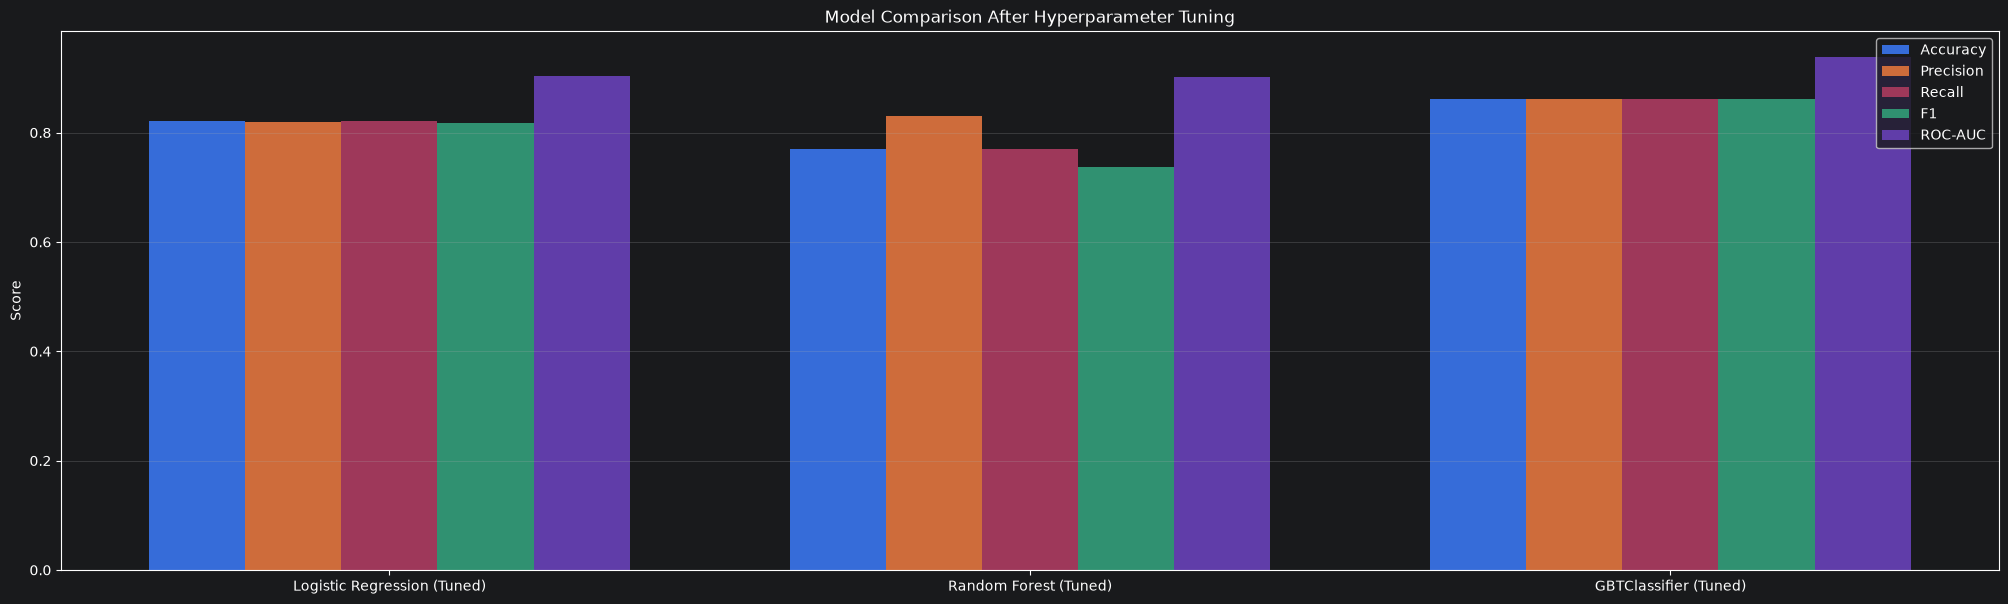

In [59]:
#biểu đồ so sánh
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

x = np.arange(len(results_tuned))
width = 0.15

plt.figure(figsize=(25,7))

for i, metric in enumerate(metrics):
    plt.bar(
        x + i*width,
        results_tuned[metric],
        width,
        label=metric
    )

plt.xticks(
    x + width*2,
    results_tuned["Model"]
)

plt.ylabel("Score")
plt.title("Model Comparison After Hyperparameter Tuning")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

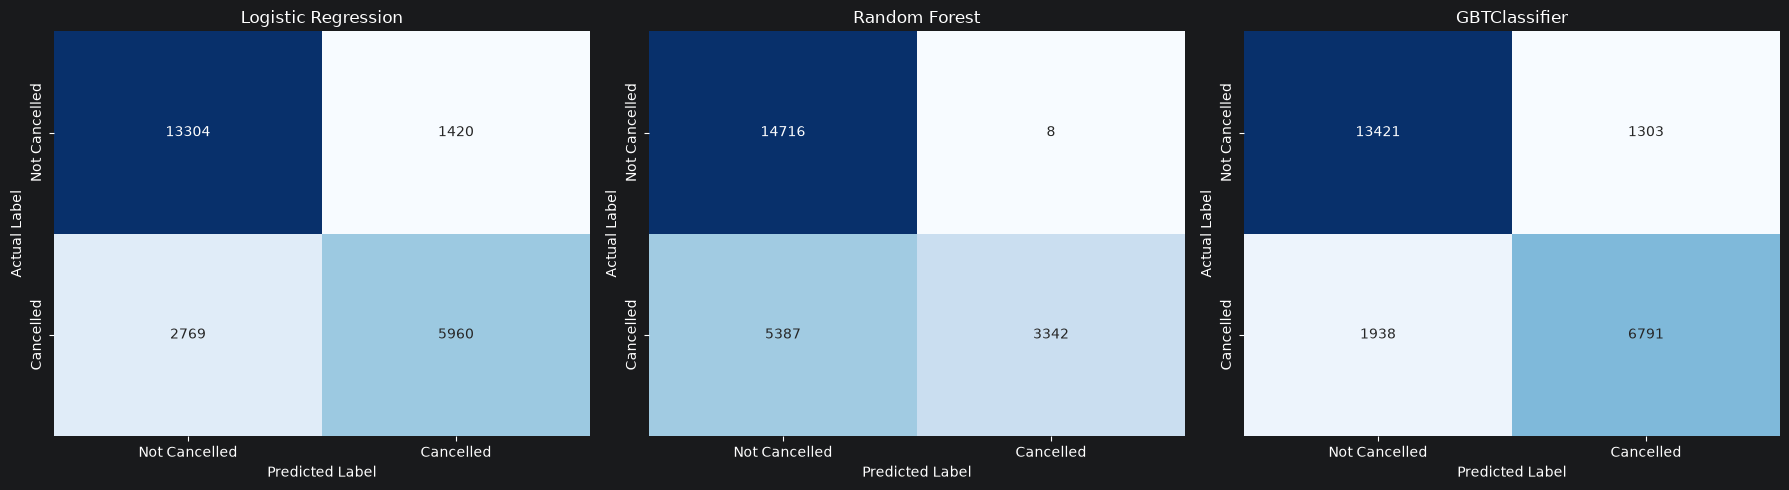

In [48]:
#confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# Lấy label thực tế


y_true = pred_lr_tuned.select("label") \
    .rdd.flatMap(lambda x: x) \
    .collect()


# Lấy prediction của từng model


y_pred_lr = pred_lr_tuned.select("prediction") \
    .rdd.flatMap(lambda x: x) \
    .collect()

y_pred_rf = pred_rf_tuned.select("prediction") \
    .rdd.flatMap(lambda x: x) \
    .collect()

y_pred_gbt = pred_gbt_tuned.select("prediction") \
    .rdd.flatMap(lambda x: x) \
    .collect()

# Tạo confusion matrix

cm_lr = confusion_matrix(y_true, y_pred_lr)
cm_rf = confusion_matrix(y_true, y_pred_rf)
cm_gbt = confusion_matrix(y_true, y_pred_gbt)

# Vẽ 3 confusion matrix

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    ("Logistic Regression", cm_lr),
    ("Random Forest", cm_rf),
    ("GBTClassifier", cm_gbt)
]

for ax, (model_name, cm) in zip(axes, models):

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Not Cancelled", "Cancelled"],
        yticklabels=["Not Cancelled", "Cancelled"],
        ax=ax
    )

    ax.set_title(model_name)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")

plt.tight_layout()
plt.show()

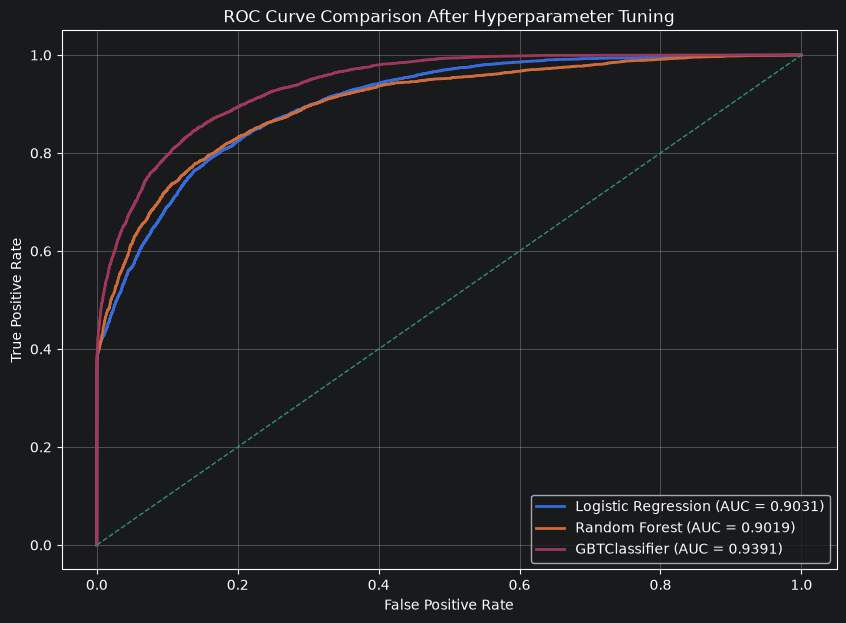

In [49]:
#
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ===== Logistic Regression =====
lr_pd = pred_lr_tuned.select(
    "label",
    "probability"
).toPandas()

lr_probs = lr_pd["probability"].apply(lambda x: float(x[1]))

fpr_lr, tpr_lr, _ = roc_curve(
    lr_pd["label"],
    lr_probs
)
auc_lr = auc(fpr_lr, tpr_lr)


# ===== Random Forest =====
rf_pd = pred_rf_tuned.select(
    "label",
    "probability"
).toPandas()

rf_probs = rf_pd["probability"].apply(lambda x: float(x[1]))

fpr_rf, tpr_rf, _ = roc_curve(
    rf_pd["label"],
    rf_probs
)
auc_rf = auc(fpr_rf, tpr_rf)


# ===== GBT =====
gbt_pd = pred_gbt_tuned.select(
    "label",
    "probability"
).toPandas()

gbt_probs = gbt_pd["probability"].apply(lambda x: float(x[1]))

fpr_gbt, tpr_gbt, _ = roc_curve(
    gbt_pd["label"],
    gbt_probs
)
auc_gbt = auc(fpr_gbt, tpr_gbt)


# ===== Plot =====
plt.figure(figsize=(10,7))

plt.plot(
    fpr_lr,
    tpr_lr,
    linewidth=2,
    label=f"Logistic Regression (AUC = {auc_lr:.4f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    linewidth=2,
    label=f"Random Forest (AUC = {auc_rf:.4f})"
)

plt.plot(
    fpr_gbt,
    tpr_gbt,
    linewidth=2,
    label=f"GBTClassifier (AUC = {auc_gbt:.4f})"
)

# đường baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison After Hyperparameter Tuning")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

In [50]:

mapping = pd.read_csv("data/feature_mapping.csv")

print(mapping.head())
print(mapping.columns)
print(mapping.shape)

   feature_index        feature_name
0              0         meal_vec_BB
1              1         meal_vec_HB
2              2         meal_vec_SC
3              3  meal_vec_Undefined
4              4         meal_vec_FB
Index(['feature_index', 'feature_name'], dtype='str')
(534, 2)


In [51]:
#lấy feature importance từ GBT
# lấy importance
importance = best_gbt.featureImportances

# chuyển sang dataframe
importance_df = pd.DataFrame({
    "feature_index": list(range(len(importance))),
    "importance": importance.toArray()
})

importance_df.head()

,feature_index,importance
0,0,0.010629
1,1,0.005633
2,2,0.002890
3,3,0.005545
4,4,0.000314


In [52]:
#ghép với feature mapping
feature_importance_df = importance_df.merge(
    mapping,
    on="feature_index",
    how="left"
)

feature_importance_df.head()

,feature_index,importance,feature_name
0,0,0.010629,meal_vec_BB
1,1,0.005633,meal_vec_HB
2,2,0.002890,meal_vec_SC
3,3,0.005545,meal_vec_Undefined
4,4,0.000314,meal_vec_FB


In [53]:
#sắp xếp giảm dần
feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
)

feature_importance_df.head(20)

,feature_index,importance,feature_name
200,200,0.259781,deposit_type_vec_Non Refund
523,523,0.106419,lead_time
5,5,0.067952,country_vec_PRT
526,526,0.048451,total_estimated_cost
531,531,0.047015,total_of_special_requests
528,528,0.043240,cancellation_rate
530,530,0.040885,required_car_parking_spaces
208,208,0.032295,agent_vec_240
206,206,0.031606,agent_vec_9
525,525,0.030206,total_nights


In [54]:
#top 20 feature quan trọng nhất
top20 = feature_importance_df.head(20)

top20

,feature_index,importance,feature_name
200,200,0.259781,deposit_type_vec_Non Refund
523,523,0.106419,lead_time
5,5,0.067952,country_vec_PRT
526,526,0.048451,total_estimated_cost
531,531,0.047015,total_of_special_requests
528,528,0.043240,cancellation_rate
530,530,0.040885,required_car_parking_spaces
208,208,0.032295,agent_vec_240
206,206,0.031606,agent_vec_9
525,525,0.030206,total_nights


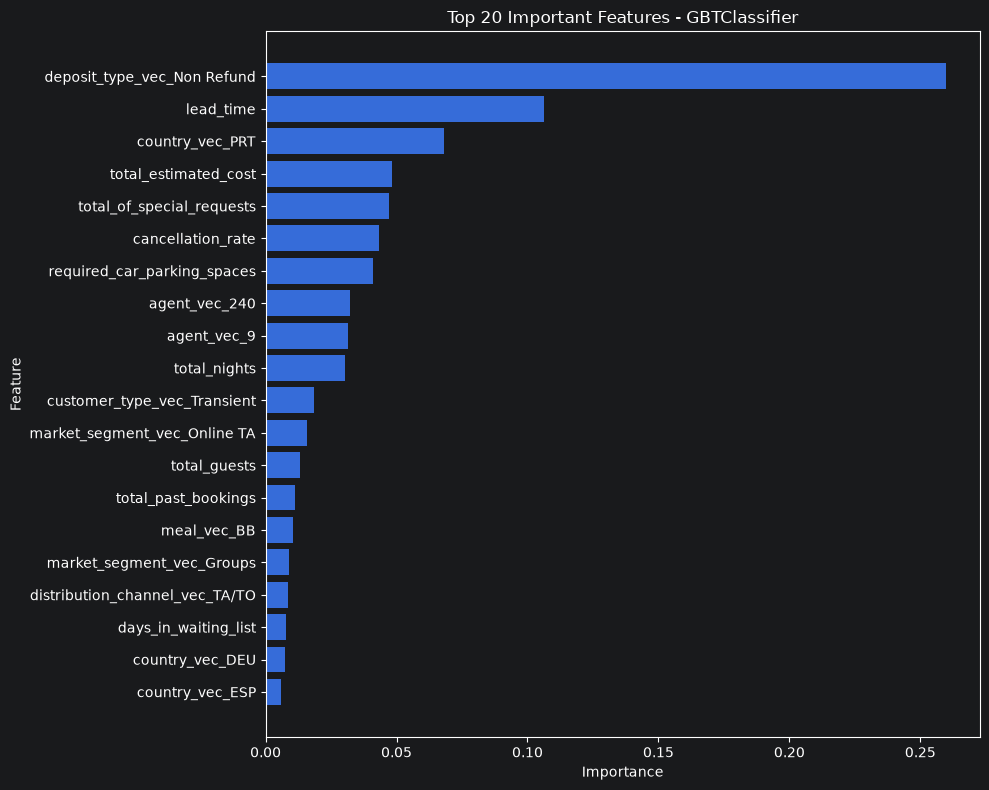

In [55]:
#biểu đồ
top20 = feature_importance_df.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20["feature_name"][::-1],
    top20["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Important Features - GBTClassifier")

plt.tight_layout()
plt.show()

In [56]:
top20[[
    "feature_name",
    "importance"
]].reset_index(drop=True)

,feature_name,importance
0,deposit_type_vec_Non Refund,0.259781
1,lead_time,0.106419
2,country_vec_PRT,0.067952
3,total_estimated_cost,0.048451
4,total_of_special_requests,0.047015
5,cancellation_rate,0.043240
6,required_car_parking_spaces,0.040885
7,agent_vec_240,0.032295
8,agent_vec_9,0.031606
9,total_nights,0.030206


In [60]:
best_gbt.write().overwrite().save("saved_models/gbt_hotel_booking")

In [61]:
mapping.to_csv(
    "saved_models/feature_mapping.csv",
    index=False
)